### Inorder to to run below cells Download data from https://amazon-reviews-2023.github.io/main.html and place them in data folder ###

In [1]:
import json
import pandas as pd

In [6]:
with open('../../data/meta_Electronics.jsonl', 'r') as f:
        first_line = json.loads(f.readline())

In [7]:
first_line

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

### Filter Items that have been observed for the first time in year 2022 or later ###

In [8]:
def filter_data(data: dict) -> bool:
        filter = False
        if int(data['details']['Date First Available'][-4:]) < 2022:
                filter = True
        return filter

# Filter out meta/product data data in 2 files based on date range
# We want latest data to be in meta_Electronics_2022_2023.jsonll file
# We want data with date < 2022 to be not considered and remain in the meta_Electronics.jsonl
# We want data with no date (thrash data) to be in meta_Electronics_2022_2023_no_date.jsonl file
with open('../../data/meta_Electronics.jsonl', 'r') as fp:
        with open('../../data/meta_Electronics_2022_2023.jsonl', 'w') as fp_out:
                with open('../../data/meta_Electronics_2022_2023_no_date.jsonl', 'w') as fp_out_no_date:
                        i = 0
                        for line in fp:
                                data = json.loads(line.strip())
                                try:
                                        if not filter_data(data):
                                                json.dump(data, fp_out)
                                                fp_out.write('\n')
                                                fp_out.flush()
                                except:
                                        json.dump(data, fp_out_no_date)
                                        fp_out_no_date.write('\n')
                                        fp_out_no_date.flush()
                        i += 1
                        if i % 10000 == 0:
                                print(f"Processed {i} lines")


### Split item to that have and does not have main_category ###

In [2]:
def filter_category(data: dict) -> bool:
        filter = False
        if data['main_category'] is None:
                filter = True
        return filter


with open('../../data/meta_Electronics_2022_2023.jsonl', 'r') as fp:
        with open('../../data/meta_Electronics_2022_2023_with_category.jsonl', 'w') as fp_out:
                with open('../../data/meta_Electronics_2022_2023_no_category.jsonl', 'w') as fp_out_no_category:
                        for line in fp:
                                data = json.loads(line.strip())
                                if not filter_category(data):
                                        json.dump(data, fp_out)
                                        fp_out.write('\n')
                                        fp_out.flush()
                                else:
                                        json.dump(data, fp_out_no_category)
                                        fp_out_no_category.write('\n')
                                        fp_out_no_category.flush()


### Explore distribution by categories ###

In [3]:
df = pd.read_json('../../data/meta_Electronics_2022_2023_with_category.jsonl', lines=True)

In [4]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Amazon Home,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,50,[PROFESSIONAL STICKER SHOP.There are 50 differ...,"[Features:, - Clear picture and exquisite prin...",3.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Watch Before Buying! Huge Waterpro...,Affoto,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Affoto', 'Color': 'Outer Space', 'S...",B0BPLX8B2K,NaN,NaN,NaN
1,Computers,"Gateway 15.6"" FHD Ultra Slim Budget Notebook, ...",4.1,15,"[【Processor】4 Core, 4 Threads, 4MB Cache, up t...","[Processor:, Intel® Pentium® Silver N5030 Proc...",189.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Watch before you order ', 'url': '...",Gateway,"[Electronics, Computers & Accessories, Compute...",{'Standing screen display size': '15.6 Inches'...,B0BYBG1PPD,NaN,NaN,NaN
2,Cell Phones & Accessories,May Chen Compatible with MacBook Pro 16 inch C...,4.5,649,[【 COMPATIBLE WITH 】 Designed to Fits Perfectl...,[May Chen High Quality Plastic Hard Shell Case...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'MOSISO Plastic Hard Shell Compati...,May Chen,"[Electronics, Computers & Accessories, Laptop ...","{'Standing screen display size': '16 Inches', ...",B0822SL7JX,NaN,NaN,NaN
3,All Electronics,"LENTION USB C Docking Station, 10 Gbps USB C&U...",4.4,16,[10-in-1 Docking Station - CB-D65 laptop docki...,[],89.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'LENTION D65 Upgrade Docking Statio...,LENTION,"[Electronics, Computers & Accessories, Laptop ...",{'Package Dimensions': '9.17 x 4.33 x 1.54 inc...,B0BKS1K986,NaN,NaN,NaN
4,All Electronics,1X (No Bluetooth) Eaglewireless Replacement To...,3.0,4,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Eaglewireless,[],{'Package Dimensions': '5.2 x 2.13 x 0.91 inch...,B09MY246CC,NaN,NaN,NaN


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='main_category'>

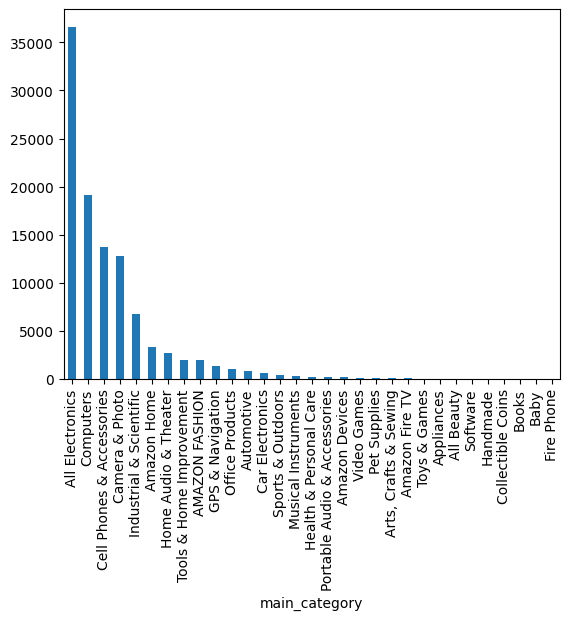

In [6]:
df['main_category'].value_counts().plot(kind='bar')

### Filter items that have atleast 100 ratings

<Axes: xlabel='main_category'>

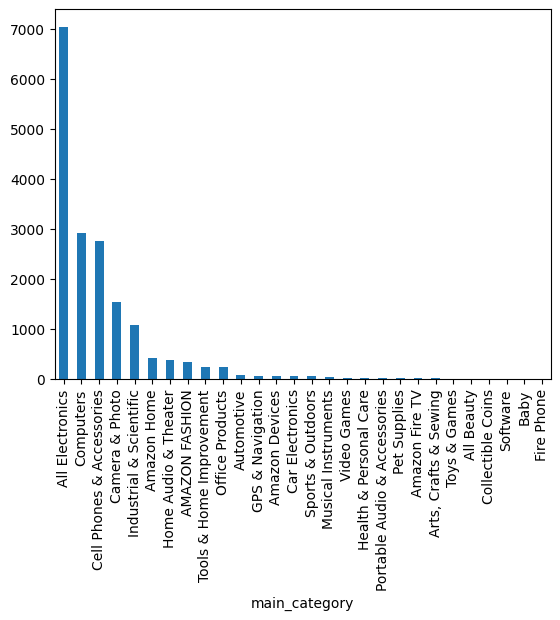

In [8]:
df_ratings_100 = df[df['rating_number'] >= 100]
df_ratings_100['main_category'].value_counts().plot(kind='bar')

### Explore distribution of ratings

<Axes: ylabel='Frequency'>

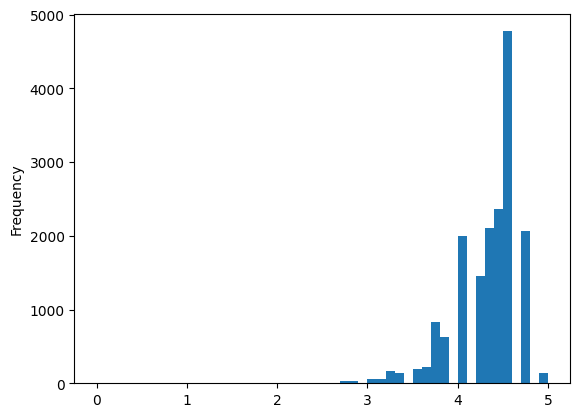

In [11]:
df_ratings_100['average_rating'].plot(kind='hist', bins=50, range=(0, 5))

### Sample 1000 items

<Axes: ylabel='Frequency'>

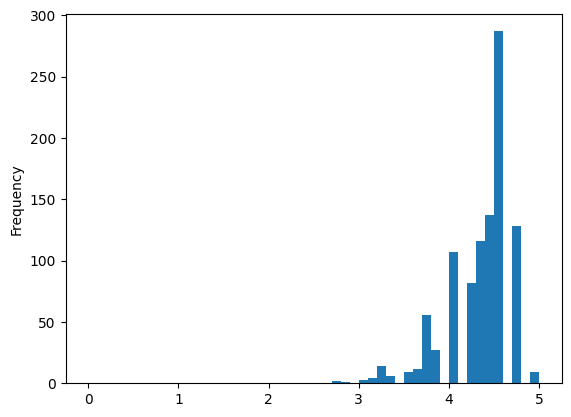

In [15]:
df_sample_1000 = df_ratings_100.sample(n=1000, random_state=20)
df_sample_1000['average_rating'].plot(kind='hist', bins=50, range=(0, 5))

<Axes: ylabel='Frequency'>

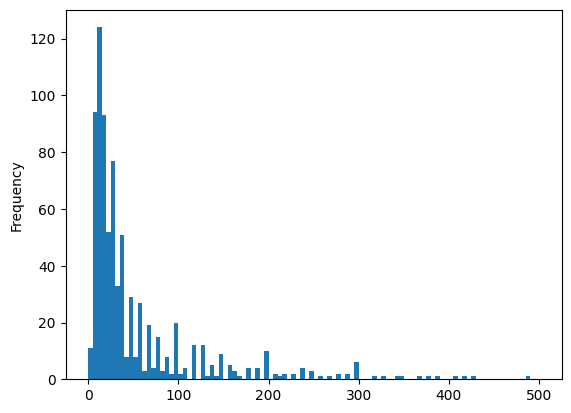

In [18]:
df_sample_1000['price'].plot(kind='hist', bins=100, range=(0, 500))

<Axes: xlabel='main_category'>

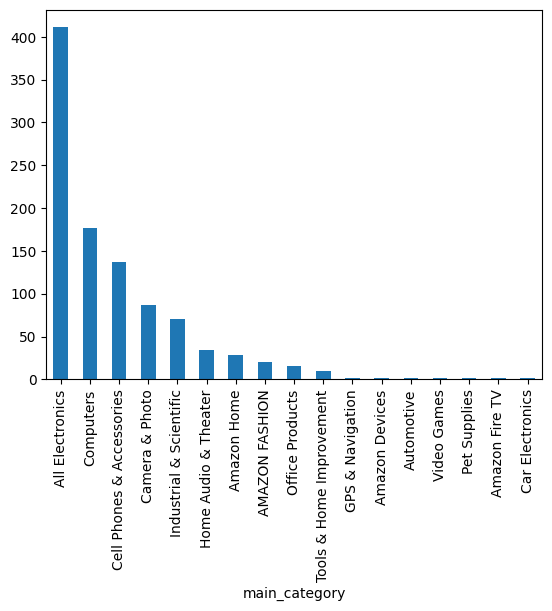

In [20]:
df_sample_1000['main_category'].value_counts().plot(kind='bar')

In [21]:
df_ratings_100.to_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl', orient='records', lines=True)

In [22]:
df_sample_1000.to_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl', orient='records', lines=True)

In [24]:
df_sample_1000.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
34639,Camera & Photo,80x100 Monocular-Telescope Low Night Vision Mo...,3.6,187,[],[],29.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': '80X100 monocular telescope high po...,MANDDDWU,"[Electronics, Camera & Photo, Binoculars & Sco...",{'Product Dimensions': '3.94 x 3.94 x 3.94 inc...,B09YHBXZC8,NaN,NaN,NaN
1239,All Electronics,"SoundPEATS Air Conduction Headphones, RunFree ...",4.0,132,[𝗨𝗻𝗯𝗲𝗮𝘁𝗮𝗯𝗹𝗲 𝗖𝗼𝗺𝗳𝗼𝗿𝘁 𝗮𝗻𝗱 𝗟𝗶𝗴𝗵𝘁𝘄𝗲𝗶𝗴𝗵𝘁 𝗗𝗲𝘀𝗶𝗴𝗻 - 🍀...,[],29.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Soundpeats RunFree Lite - The Best...,SoundPEATS,"[Electronics, Headphones, Earbuds & Accessorie...",{'Package Dimensions': '7.48 x 5.16 x 2.13 inc...,B0BRXDR9GF,NaN,NaN,NaN
17475,Computers,"𝟮𝟬𝟮𝟯 𝗟𝐚𝐭𝐞𝐬𝐭 Tablet 10.1"" Octa-Core Android 11 ...",4.3,411,[【VALUE FOR MONEY】Get all the bundled accessor...,[],179.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'The most complete tablet bundle', ...",FEONAL,"[Electronics, Computers & Accessories, Compute...","{'Standing screen display size': '10.1', 'Scre...",B0B4C98K37,NaN,NaN,NaN
18184,Tools & Home Improvement,"120PCS 6 Inch Reusable Cable Ties, Wire Ties, ...",4.8,647,[Super Valuable: 120PCS cable straps is enough...,[],8.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': '120PCS Black Reusable Cable Ties',...",Mvyc,"[Electronics, Accessories & Supplies, Cord Man...","{'Manufacturer': 'Mvyc', 'Part Number': 'CAKF2...",B0B564JMB5,NaN,NaN,NaN
55504,All Electronics,"CHIFENCHY 2 Packs Golf Speaker with Magnetic, ...",4.2,144,[GOLF PORTABLE BLUETOOTH SPEAKER: Designed in ...,[],99.98,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Honest Review of Ampcaddy Golf Blu...,CHIFENCHY,"[Electronics, Portable Audio & Video, Portable...",{'Product Dimensions': '3.74 x 1.57 x 3.54 inc...,B0BDYW4FC4,NaN,NaN,NaN


### Extract ratings that match sampled data

In [25]:
df_ratings_100 = pd.read_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100.jsonl', lines=True)
df_sample_1000 = pd.read_json('../../data/meta_Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl', lines=True)

In [32]:
with open("../../data/Electronics.jsonl", "r") as fp:
        with open("../../data/Electronic_2022_2023_with_category_ratings_100.jsonl", "w") as fp_out:
                id_list = set(df_ratings_100['parent_asin'].values)
                i = 0
                for line in fp:
                        data = json.loads(line.strip())
                        if data['parent_asin'] in id_list:
                                json.dump(data, fp_out)
                                fp_out.write('\n')
                                fp_out.flush()
                        i += 1
                        if i % 10000 == 0:
                                print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

In [33]:
with open("../../data/Electronic_2022_2023_with_category_ratings_100.jsonl", "r") as fp:
        with open("../../data/Electronic_2022_2023_with_category_ratings_100_sample_1000.jsonl", "w") as fp_out:
                id_list = set(df_sample_1000['parent_asin'].values)
                i = 0
                for line in fp:
                        data = json.loads(line.strip())
                        if data['parent_asin'] in id_list:
                                json.dump(data, fp_out)
                                fp_out.write('\n')
                                fp_out.flush()
                        i += 1
                        if i % 10000 == 0:
                                print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin